In [9]:
import os
from dotenv import load_dotenv
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()

True

In [19]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [20]:
llm = ChatOpenAI(model="gpt-4o")

In [21]:
def super_bot(state: State):
    return { "messages": [llm.invoke(state["messages"])] }

In [22]:
graph = StateGraph(State)

graph.add_node("super_bot", super_bot)

graph.add_edge(START, "super_bot")
graph.add_edge("super_bot", END)

graph_builder = graph.compile()

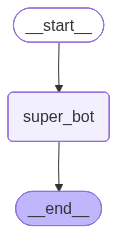

In [23]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [24]:
graph_builder.invoke({ "messages": "My name is ido" })

{'messages': [HumanMessage(content='My name is ido', additional_kwargs={}, response_metadata={}, id='2e4271d2-3e47-431a-a9c3-a11cdb50baf2'),
  AIMessage(content='Nice to meet you, Ido! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 11, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6084d5b3db', 'id': 'chatcmpl-Dlh4oWo01gg9G7bo5RVq9SG7XUWqn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7fba-44e7-7d43-86d2-e6e236eee700-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 15, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}